# Tier 19: thermal

Plan 028. Losses become heat; the heat sizes a ram-air heat exchanger and costs cooling drag (airplane mode) or
fan power (hover); lumped machine temperatures turn the machines' power ratings into continuous ratings that short
hover and engine-out peaks may exceed.

| Piece | Model | Source |
|---|---|---|
| Heat loads | named `HeatLoad(source, power_W, count)` per flight point: motor, rotor gearbox, generator, step-up gearbox, battery | the losses the models already compute |
| Heat exchanger | 1.0 kW/kg at a 40 K coolant-to-air difference; air flow Q / (eps cp dT); dp ~ m^2 / rho; pumping power m dp / rho | Kellermann et al., *Aerospace* 2021, 8(1), 3; Potamiti et al., *Aeronaut. J.* 128 (2024) |
| Cooling drag / fans | D V = pumping power (ram), fan power = pumping power / 0.6 (hover); no Meredith recovery credited | Meredith, ARC R&M 1683 (1935) |
| Machine and pack temperature | C dT/dt = Q - (T - T_c)/R, exact over each interval; R from the continuous rating; C = 500 (machines) or 1,000 (pack) J/(kg K) x mass; the cooler sees (T - T_c)/R | Incropera and DeWitt ch. 5 |

The switch `HaloAssumptions.thermal_model` is **off by default**; the reference (900 kg, 210 kt, 13,639 lb) is
unchanged.

```powershell
uv run jupyter lab notebooks/tier19_thermal
```

In [1]:
import sys
import time
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
for path in (repo_root / "src", repo_root):     # this checkout's package even if another one is installed
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain.components.heat_exchanger import RamAirHeatExchanger
from aircraft_closure.powertrain.components.thermal import LumpedThermalModel
from examples.halo_sizing import HaloAssumptions, solve_halo_sizing

# Plan 030 made the thermal model the default; this notebook keeps comparing against the thermal-off plan 027
# reference (13,639 lb).
from functools import partial
from examples.halo_sizing import HaloAssumptions as _HaloAssumptions, solve_halo_sizing as _solve_halo_sizing
HaloAssumptions = partial(_HaloAssumptions, thermal_model=False)
solve_halo_sizing = partial(_solve_halo_sizing, assumptions=HaloAssumptions())

check_log = []


def check(name, passed):
    # Record and print one named verification.
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})

## 1. Lumped capacitance: closed form, steady state and short-time ratings

T(t) = T_ss + (T_0 - T_ss) e^(-t/tau) with T_ss = T_c + Q R and tau = R C. R is set so that the continuous loss
holds the machine exactly at the limit (150 C over a 60 C coolant). A hold of duration t from the coolant
temperature then allows Q / Q_cont = 1 / (1 - e^(-t/tau)).

PASS  steady state at the continuous loss is the 150 C limit
PASS  one time constant covers 1 - 1/e of the rise
PASS  None start is the steady state
PASS  zero loss relaxes to the coolant
PASS  two 30 s intervals equal one 60 s interval (exact propagation)


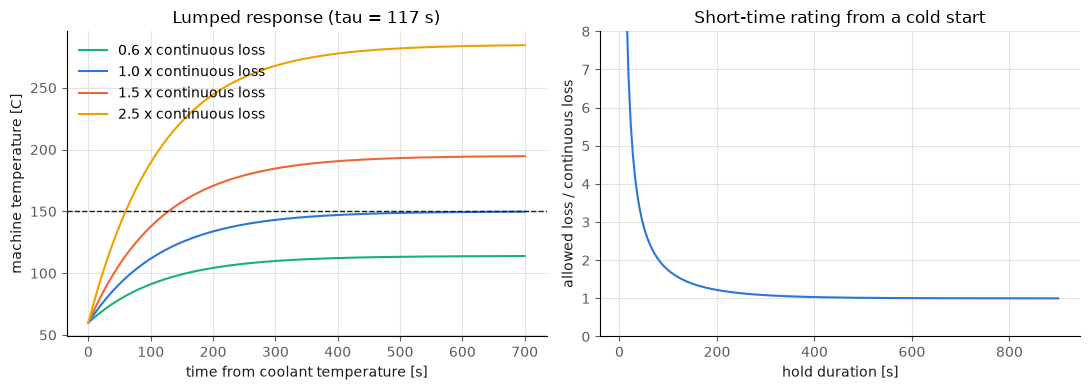

In [2]:
model = LumpedThermalModel()
capacity_J_K, loss_continuous_W = 500.0 * 70.0, 27000.0          # a ~70 kg machine, ~27 kW continuous loss
resistance_K_W = (model.temperature_max_C - model.temperature_coolant_C) / loss_continuous_W
tau_s = capacity_J_K * resistance_K_W
time_s = np.linspace(0, 6 * tau_s, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ratio, color in ((0.6, aqua), (1.0, blue), (1.5, orange), (2.5, yellow)):
    temperature_C = model.temperature_end_C(ratio * loss_continuous_W, time_s, capacity_J_K, resistance_K_W, 60.0)
    ax1.plot(time_s, temperature_C, color=color, label=f"{ratio:.1f} x continuous loss")
ax1.axhline(model.temperature_max_C, color=ink, lw=1, ls="--")
ax1.set(xlabel="time from coolant temperature [s]", ylabel="machine temperature [C]",
        title=f"Lumped response (tau = {tau_s:.0f} s)")
ax1.legend(frameon=False)
duration_s = np.linspace(5, 900, 200)
ax2.plot(duration_s, 1 / (1 - np.exp(-duration_s / tau_s)), color=blue)
ax2.set(xlabel="hold duration [s]", ylabel="allowed loss / continuous loss", ylim=(0, 8),
        title="Short-time rating from a cold start")
plt.tight_layout()

steady = model.temperature_end_C(loss_continuous_W, 1e7, capacity_J_K, resistance_K_W, 60.0)
check("steady state at the continuous loss is the 150 C limit", abs(steady - 150.0) < 1e-9)
one_tau = model.temperature_end_C(loss_continuous_W, tau_s, capacity_J_K, resistance_K_W, 60.0)
check("one time constant covers 1 - 1/e of the rise", abs((one_tau - 60) / 90 - (1 - np.exp(-1))) < 1e-12)
check("None start is the steady state", abs(model.temperature_end_C(loss_continuous_W, 60.0, capacity_J_K,
                                                                    resistance_K_W) - 150.0) < 1e-12)
check("zero loss relaxes to the coolant", abs(model.temperature_end_C(0.0, 1e7, capacity_J_K, resistance_K_W,
                                                                      140.0) - 60.0) < 1e-9)
half = model.temperature_end_C(2 * loss_continuous_W, 30.0, capacity_J_K, resistance_K_W, 60.0)
check("two 30 s intervals equal one 60 s interval (exact propagation)",
      abs(model.temperature_end_C(2 * loss_continuous_W, 30.0, capacity_J_K, resistance_K_W, half)
          - model.temperature_end_C(2 * loss_continuous_W, 60.0, capacity_J_K, resistance_K_W, 60.0)) < 1e-9)

## 2. Ram-air heat exchanger: cooling drag, fan power and the hot day

Air flow m = Q / (eps cp dT) with dT = T_coolant - T_ambient; pressure loss dp_ref (m/m_ref)^2 rho_ref/rho;
pumping power m dp / rho, so drag and fan power grow as Q^3 / (dT^3 Q_rated^2). The required rating is
Q x 40 K / dT, so the 4,000 ft / 95 F hover (dT = 25 K) needs 1.6 x its heat.

PASS  zero heat: zero flow, drag and fan power
PASS  drag ~ heat^3
PASS  ram drag x speed = pumping power
PASS  hot day: required rating = heat x 40 K / dT
hot day dT 25.0 K: 100 kW needs a 160 kW rating and 11.9 kW of fan power at the 150 kW cooler


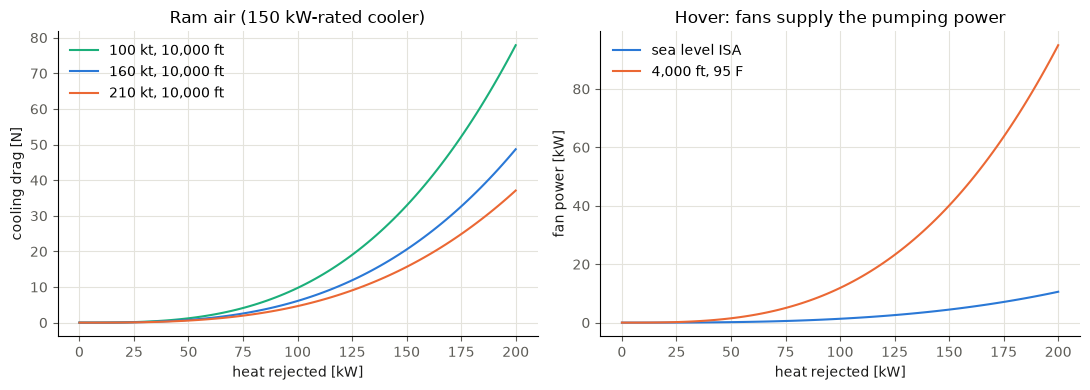

In [3]:
exchanger = RamAirHeatExchanger(power_rated_W=150e3)
cruise_atmosphere = asb.Atmosphere(altitude=10000 * u.foot)
hot = asb.Atmosphere(altitude=4000 * u.foot, temperature_deviation=27.7)
heat_W = np.linspace(0, 200e3, 101)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for velocity_kt, color in ((100, aqua), (160, blue), (210, orange)):
    r = exchanger.evaluate(heat_W, cruise_atmosphere, velocity_kt * u.knot)
    ax1.plot(heat_W / 1e3, r.drag_N, color=color, label=f"{velocity_kt} kt, 10,000 ft")
ax1.set(xlabel="heat rejected [kW]", ylabel="cooling drag [N]", title="Ram air (150 kW-rated cooler)")
ax1.legend(frameon=False)
for atmosphere, label, color in ((asb.Atmosphere(altitude=0), "sea level ISA", blue), (hot, "4,000 ft, 95 F", orange)):
    r = exchanger.evaluate(heat_W, atmosphere, 0.0, fan=True)
    ax2.plot(heat_W / 1e3, r.power_fan_W / 1e3, color=color, label=label)
ax2.set(xlabel="heat rejected [kW]", ylabel="fan power [kW]", title="Hover: fans supply the pumping power")
ax2.legend(frameon=False)
plt.tight_layout()

zero = exchanger.evaluate(0.0, cruise_atmosphere, 100.0)
check("zero heat: zero flow, drag and fan power", zero.mass_flow_air_kg_s == zero.drag_N == zero.power_fan_W == 0)
r1, r2 = exchanger.evaluate(50e3, cruise_atmosphere, 100.0), exchanger.evaluate(100e3, cruise_atmosphere, 100.0)
check("drag ~ heat^3", abs(r2.drag_N / r1.drag_N - 8) < 1e-9)
check("ram drag x speed = pumping power", abs(r1.drag_N * 100.0 - r1.power_pumping_W) < 1e-9)
hot_r = exchanger.evaluate(100e3, hot, 0.0, fan=True)
check("hot day: required rating = heat x 40 K / dT", abs(hot_r.power_heat_equivalent_W
                                                          - 100e3 * 40 / hot_r.delta_temperature_C) < 1e-6)
print(f"hot day dT {hot_r.delta_temperature_C:.1f} K: 100 kW needs a {hot_r.power_heat_equivalent_W / 1e3:.0f} kW rating "
      f"and {hot_r.power_fan_W / 1e3:.1f} kW of fan power at the 150 kW cooler")

## 3. The Halo with the thermal model

The reference (thermal off) and the same requirements with `thermal_model=True`. With thermal on the solve starts
from the thermal-off design. The machines start the mission at the coolant temperature; the engine-out hover
continues from the end of the take-off hover; the hot-day hover from the end of the mission; the 4,000 ft hover
requirement is a 60 s hover from cold; airplane-mode requirement points are steady (continuous).

In [4]:
t0 = time.time()
reference = solve_halo_sizing()
time_reference_s = time.time() - t0
t0 = time.time()
sized = solve_halo_sizing(assumptions=HaloAssumptions(thermal_model=True))
time_thermal_s = time.time() - t0
print(f"reference (thermal off): {reference.mass_takeoff_kg / u.lbm:,.0f} lb ({time_reference_s:.0f} s)")
print(f"thermal on:              {sized.mass_takeoff_kg / u.lbm:,.0f} lb ({time_thermal_s:.0f} s)")
check("reference unchanged: 13,639 lb", abs(reference.mass_takeoff_kg / u.lbm - 13639) < 5)
check("thermal sizing closes with every margin", sized.min_margin > -1e-6 and abs(sized.closure_residual_kg) < 1e-3)
masses_ref, masses = dict(reference.powertrain_masses_kg), dict(sized.powertrain_masses_kg)
print(f"\n{'item':<18}{'off kg':>9}{'on kg':>9}")
for name in masses:
    print(f"{name:<18}{masses_ref.get(name, 0.0):9.1f}{masses[name]:9.1f}")
hx = sized.heat_exchanger
print(f"\nheat exchanger {hx['power_rated_W'] / 1e3:.0f} kW rated (at 40 K), {hx['mass_kg']:.0f} kg; rotor gearbox rating "
      f"{hx['power_rated_gearbox_W'] / 1e3:.0f} kW")
for name, m in hx["machines"].items():
    print(f"{name}: continuous {m['power_rated_W'] / 1e3:.0f} kW, {m['mass_kg']:.1f} kg, continuous loss "
          f"{m['power_loss_continuous_W'] / 1e3:.1f} kW, tau {m['time_constant_s']:.0f} s")
print("\nbinding:", ", ".join(sized.binding))

CasADi - 2026-10-04 12:15:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:15:37 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:17:19 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


CasADi - 2026-10-04 12:17:20 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 628, col 0).") [.../casadi/core/oracle_function.cpp:408]


reference (thermal off): 13,639 lb (105 s)
thermal on:              14,037 lb (150 s)
PASS  reference unchanged: 13,639 lb
PASS  thermal sizing closes with every margin

item                 off kg    on kg
turboshaft            421.7    421.7
generator             162.5    122.0
battery               378.6    412.3
motor                 138.8    115.9
gearbox               345.1    356.5
propulsor             588.9    610.8
generator_gearbox     174.6    174.7
heat_exchanger          0.0    133.5

heat exchanger 133 kW rated (at 40 K), 133 kg; rotor gearbox rating 708 kW
motor: continuous 570 kW, 57.9 kg, continuous loss 24.3 kW, tau 107 s
generator: continuous 606 kW, 61.0 kg, continuous loss 25.9 kW, tau 106 s
battery: continuous 738 kW, 412.3 kg, continuous loss 126.9 kW, tau 114 s

binding: engine-out hover 3/3: battery end voltage_V, rotor_radius_m, whirl flutter torsion per rev (max_speed), hover: gearbox power_input_W, hover: propulsor power_shaft_W, hot-day hover: heat_exchang

In [5]:
print(f"{'point':<22}{'motor':>7}{'gbx':>6}{'gen':>6}{'g-gbx':>6}{'batt':>6}{'Q kW':>7}{'D_c N':>7}{'fan kW':>7}"
      f"{'Qeq kW':>8}{'T_mot':>7}{'T_gen':>7}{'T_bat':>7}{'P_mot/rated':>12}")
motor_rated_W = hx["machines"]["motor"]["power_rated_W"]
for row in sized.thermal_trace:
    h = row["heat_W"]
    print(f"{row['label']:<22}{h['motor'] / 1e3:7.1f}{h['gearbox'] / 1e3:6.1f}{h['generator'] / 1e3:6.1f}"
          f"{h.get('generator_gearbox', 0) / 1e3:6.1f}{h['battery'] / 1e3:6.1f}{row['power_heat_W'] / 1e3:7.1f}"
          f"{row['drag_cooling_N']:7.1f}{row['power_fan_W'] / 1e3:7.2f}{row['power_heat_equivalent_W'] / 1e3:8.1f}"
          f"{row['temperatures_end_C']['motor']:7.1f}{row['temperatures_end_C']['generator']:7.1f}"
          f"{row['temperatures_end_C']['battery']:7.1f}"
          f"{row['power_shaft_motor_W'] / motor_rated_W:12.2f}")
rows = sized.thermal_trace
check("the exchanger rating covers every point", max(r["power_heat_equivalent_W"] for r in rows)
      <= hx["power_rated_W"] * (1 + 1e-6))
check("the hot-day hover sizes the exchanger",
      max(rows, key=lambda r: r["power_heat_equivalent_W"])["label"] == "hot-day hover")
check("every machine within 150 C and the pack within 60 C",
      all(r["temperatures_end_C"][n] <= 150 + 1e-3 for r in rows for n in ("motor", "generator"))
      and all(r["temperatures_end_C"]["battery"] <= 60 + 1e-3 for r in rows))
eo = [r for r in rows if r["label"].startswith("engine-out")]
check("the pack's thermal mass absorbs the engine-out battery heat (heat to the cooler < loss)",
      all(r["power_to_coolant_W"]["battery"] < r["heat_W"]["battery"] for r in eo))
check("cooling drag in airplane mode, fans in hover",
      all((r["power_fan_W"] > 0 and r["drag_cooling_N"] == 0) if r["mode"] == "hover"
          else (r["drag_cooling_N"] > 0 and r["power_fan_W"] == 0) for r in rows))
check("a hover peak exceeds the motor's continuous rating",
      max(r["power_shaft_motor_W"] for r in rows if r["mode"] == "hover") > motor_rated_W)

point                   motor   gbx   gen g-gbx  batt   Q kW  D_c N fan kW  Qeq kW  T_mot  T_gen  T_bat P_mot/rated
take-off hover           53.5  37.2  51.1  37.1   3.3   25.4    0.0   0.03    41.2  102.4   98.4   25.4        1.09
climb                    48.2  29.1  38.7  28.7   3.5   81.2    5.1   0.00    66.0  148.8  127.0   26.0        0.85
cruise 1/4               26.2  18.5  30.2  21.1   0.0   58.0    1.5   0.00    35.1  108.5  112.4   25.0        0.54
cruise 2/4               25.5  18.0  29.4  20.2   0.0   54.9    1.3   0.00    34.2  107.1  111.1   25.0        0.53
cruise 3/4               24.8  17.5  28.7  19.4   0.0   53.6    1.2   0.00    33.3  105.9  109.9   25.0        0.51
cruise 4/4               24.2  17.1  28.1  18.7   0.1   52.4    1.1   0.00    32.6  104.7  108.8   25.0        0.50
reserve loiter           22.7  14.8  26.8  17.2   0.0   49.8    1.2   0.00    30.8  101.9  106.6   25.0        0.43
descent                  14.2   7.4  21.5   7.6   0.3   38.4    0.5   0.

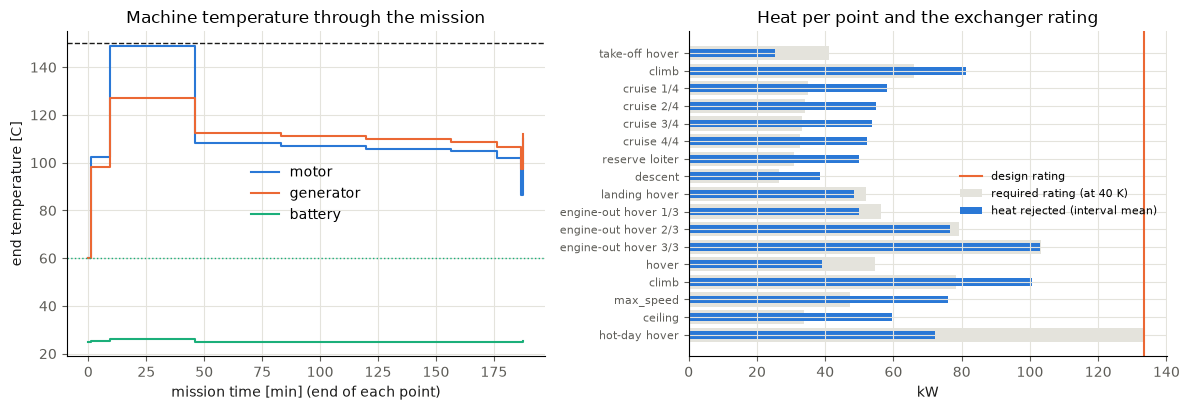

In [6]:
mission_rows = [r for r in rows if r["duration_s"] is not None and not r["label"].startswith("engine-out")]
engine_out_rows = [r for r in rows if r["label"].startswith("engine-out")]
time_end_s = np.cumsum([r["duration_s"] for r in mission_rows])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
for name, color in (("motor", blue), ("generator", orange), ("battery", aqua)):
    ax1.step(np.concatenate([[0], time_end_s]) / 60,
             [mission_rows[0]["temperatures_end_C"][name] * 0 + (25.0 if name == "battery" else 60.0)]
             + [r["temperatures_end_C"][name] for r in mission_rows], where="post", color=color, label=name)
ax1.axhline(150, color=ink, lw=1, ls="--")
ax1.axhline(60, color=aqua, lw=1, ls=":")
ax1.set(xlabel="mission time [min] (end of each point)", ylabel="end temperature [C]",
        title="Machine temperature through the mission")
ax1.legend(frameon=False)
labels = [r["label"] for r in rows]
heat_kW = np.array([r["power_heat_W"] for r in rows]) / 1e3
required_kW = np.array([r["power_heat_equivalent_W"] for r in rows]) / 1e3
y = np.arange(len(rows))
ax2.barh(y, required_kW, color=grid_color, label="required rating (at 40 K)")
ax2.barh(y, heat_kW, height=0.45, color=blue, label="heat rejected (interval mean)")
ax2.axvline(hx["power_rated_W"] / 1e3, color=orange, lw=1.5, label="design rating")
ax2.set_yticks(y, labels, fontsize=8)
ax2.invert_yaxis()
ax2.set(xlabel="kW", title="Heat per point and the exchanger rating")
ax2.legend(frameon=False, fontsize=8)
plt.tight_layout()

## 4. Summary

In [7]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

17 / 17 notebook checks passed


In [8]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 498 tests in 531.908s

OK (skipped=1)
